# Cosine Intermezzo: Cosine similarity explained and a refresher of geometrics.

- What was a cosine
- What is cosine similarity
- What is a normalized vector. 
  - Why does cosine similarity not need normalized vectors?

(Design choice: Custom functions can be found throughout the notebook.)

In [ ]:
# import
import numpy as np
import matplotlib.pyplot as plt

### Cosine

https://www.mathsisfun.com/sine-cosine-tangent.html

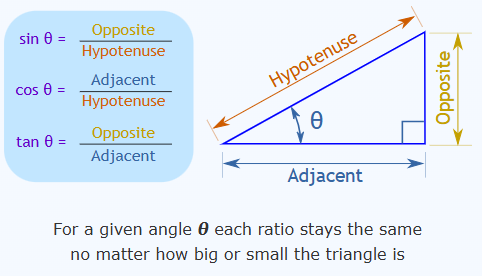

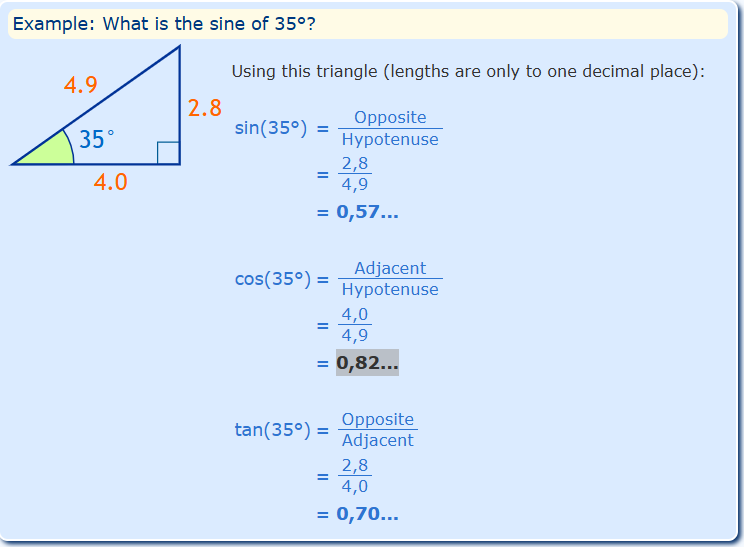

In [ ]:
ran = 360
poi = 45 # degree
print(f"{poi} degree is {round(np.radians(poi), 2)} radian.")

poi = np.radians(poi)
# poi = 0.75

# poi = 2
# ---

xs = np.radians(np.linspace(0, ran, 101))

plt.hlines(0, xs.min(), xs.max(), colors='k')

plt.plot(xs, np.sin(xs), label='sin')
plt.plot(xs, np.cos(xs), label='cos')
# plt.plot(xs, np.sin(xs)/np.cos(xs), label='tan')
# plt.plot(xs, np.tan(xs), label='tan')
# plt.plot(xs, np.cos(xs) + np.sin(xs), label='cos')


plt.scatter([poi, poi], [np.sin(poi), np.cos(poi)], c= 'r', marker='x')

plt.legend()
plt.show()

In [ ]:
np.cos(poi)

In [ ]:
# Use np.acos to convert radian back to degrees
np.degrees(np.arccos(0.7072))

### Cosine similarity

Cosine similarity finds vectors that are pointing in the same direction. It does not take the magnitude of the direction into account. 

(What would the magnitude represent in the context of sentence embedding?)

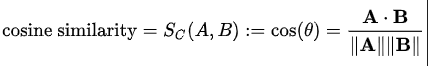

In [ ]:
# vectors
x = np.array([4,4])
y1 = np.array([6,0])
y2 = np.array([4,0])

In [ ]:
# plot vectors
V = np.array([x, y1, y2])
origin = np.array([[0, 0, 0],[0, 0, 0]]) # origin point

plt.quiver(0, 0, x[0], x[1], color= 'b', angles='xy', scale_units='xy', scale=1, label= f"x: {x}")
plt.quiver(0, 0, y1[0], y1[1], color= 'darkred', angles='xy', scale_units='xy',scale=1, label= f"y1: {y1}")
plt.quiver(0, 0, y2[0], y2[1], color= 'lightcoral', lw=0, angles='xy', scale_units='xy', scale=1, label= f"y2: {y2}") # https://github.com/matplotlib/matplotlib/issues/28298

# x-lim and y-lim
plt.xlim(-1, 8)
plt.ylim(-1, 8)

plt.legend()
plt.title("Vector projection")
plt.show()


In [ ]:
def cos_sim(x, y):
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

cos_sim(x, y1)

print(f"Similarity score x vs y1: {cos_sim(x, y1)}")
print(f"Similarity score x vs y2: {cos_sim(x, y2)}")
print(f"The scores are the same: {cos_sim(x, y1) == cos_sim(x, y2)}")

In [ ]:
# even can calculate radian back to degrees between vectors
print(f"Angle in degrees (x vs y1): {np.degrees(np.arccos(cos_sim(x, y1)))}")
print(f"Angle in degrees (x vs y2): {np.degrees(np.arccos(cos_sim(x, y2)))}")

In [ ]:
np.degrees(np.arccos(cos_sim(x, y2)))

### Vector normalization

A normalized vector has a length/magnitude equal to 1. This is achieved by dividing the current vector by its current length.
For determining the length we use a formula based on the Pythagorean theorem, where $a$ and $b$ represent the element in the vector and $c$ the length of the vector: $\sqrt{a^2 + b^2} = \sqrt{c^2}$


In [ ]:
# function of description above
def get_length(matrix):
    """Calculate the length of a vector"""
    length = np.sqrt(
        np.sum(
            np.power(
                matrix, 
                2
            ),
        axis=1
        )
    )

    return length

# function to divide vector by length
# (..probably there is a numpy function for it.. but i failed to find it)
def normalize(matrix, scales):
    """Divide elements in matrix by given scale"""
    return np.array([vector / scales[idx] for idx, vector in enumerate(matrix)])

In [ ]:
# vectors
x = np.array([4,4])
y1 = np.array([6,0])
y2 = np.array([4,0])

# place it in a matrix
M = np.array([x, y1, y2])
M

In [ ]:
# plot vectors
plt.quiver(0, 0, M[0][0], M[0][1], color= 'b', angles='xy', scale_units='xy', scale=1, label= f"x: {x}")
plt.quiver(0, 0, M[1][0], M[1][1], color= 'darkred', angles='xy', scale_units='xy',scale=1, label= f"y1: {y1}")
plt.quiver(0, 0, M[2][0], M[2][1], color= 'lightcoral', lw=0, angles='xy', scale_units='xy', scale=1, label= f"y2: {y2}") # https://github.com/matplotlib/matplotlib/issues/28298

# x-lim and y-lim
plt.xlim(-1, 8)
plt.ylim(-1, 8)

plt.legend()
plt.title("Vector projection")
plt.show()

In [ ]:
# get length of vectors
M_length = get_length(M)
M_length

In [ ]:
# module function
np.linalg.norm(M, ord=2, axis=1)

By dividing the vector coordinates by its length, we scale it to a length equal to 1. A vector that has a length equal to 1 is also known as the unit vector ($u$).

 $\frac{v}{|| v ||} = u$

In [ ]:
# divide the vectors by there length to get normalized vectors
M = normalize(M, M_length)
M

In [ ]:
# plot vectors
plt.quiver(0, 0, M[0][0], M[0][1], color= 'b', angles='xy', scale_units='xy', scale=1, label= f"x: {x}")
plt.quiver(0, 0, M[1][0], M[1][1], color= 'darkred', angles='xy', scale_units='xy',scale=1, label= f"y1: {y1}")
plt.quiver(0, 0, M[2][0], M[2][1], color= 'lightcoral', lw=0, angles='xy', scale_units='xy', scale=1, label= f"y2: {y2}") # https://github.com/matplotlib/matplotlib/issues/28298

# plot unit circle (https://www.geeksforgeeks.org/python/how-to-draw-a-circle-using-matplotlib-in-python/)
theta = np.linspace(0, 2 * np.pi, 101)
plt.plot(np.cos(theta), np.sin(theta), c='k')

# x-lim and y-lim
plt.xlim(-1.5, 2)
plt.ylim(-1.25, 1.5)

plt.legend()
plt.title("Vector projection (Normalized)")
plt.show()

The cosine similarity is now equal to the dot product of the vectors.

Dot product is calculated as follow:

$ v \cdot w = dot$

In [ ]:
print(f"Cosine similarity score x vs y1: {cos_sim(M[0], M[1])}")

In [ ]:
print(f"Dot product x vs y1: {np.dot(M[0], M[1])}")

#### Why cosine similarity does not need normalized vectors

NOTE: This also explains why the cosine similarity score can handle vectors that are not normalized. It already uses the unit vectors in its formula: 

(All vectors are scaled to their unit vector:)

$\frac{v}{|| v ||} = u$

(Then the dot product is calculated, which now equals $cos(\theta)$)

$ v \cdot w = dot$


(Resulting in the cosine similarity score)

$cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$